# (27) Animate recon mp4

host = ```chewie/yoru```, device = ```cuda:0```

**Motivation**:  <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## anim setup

In [3]:
from utils.animation import animate_recons


anim_dir = pjoin(tmp_dir, 'animations/true_and_recon')
os.makedirs(anim_dir, exist_ok=True)

print(sorted(os.listdir(anim_dir)))

['kyoto_translate_crop32.mp4', 'mnist-to-emnist_rotate-4.mp4', 'mnist-to-omni_rotate-4.mp4', 'mnist_rotate-4.mp4']

## MNIST to Omniglot generalize?

### load MNIST model

In [4]:
a = 'poisson_MNIST+rotate_t-(16,16)_b-1_kms-(128,8,3)_fwd-(3,7)_prob_<ngd|lin>'
b = 'b200-ep200-lr(0.001)_temp(0.05)_gr(150)_fwd:lamb3+z7_fit:dt+sig_ClampDec:1.15_(2025_08_26,10:47)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

200

### make Omniglot feeder

In [5]:
from main.datafeeder import RotateFeeder

vld_omni = make_dataset('Omniglot', device=tr.feeder_vld.device)[1]

feeder_omni = tr.feeder_vld.fork(
    reinit=True,
    x=vld_omni[0],
    y=vld_omni[1],
    shuffle=True,
    drop_last=True,
    batch_size=500,
)
feeder_omni.apply_anneal(-1)

4.0

In [6]:
tr.feeder_vld.n_samples, feeder_omni.n_samples

(10000, 13180)

In [7]:
tr.feeder_vld.batch_size, feeder_omni.batch_size

(200, 500)

In [8]:
len(tr.feeder_vld), len(feeder_omni)

(50, 26)

100%|█████████████████████████████████| 26/26 [02:37<00:00,  6.04s/it]


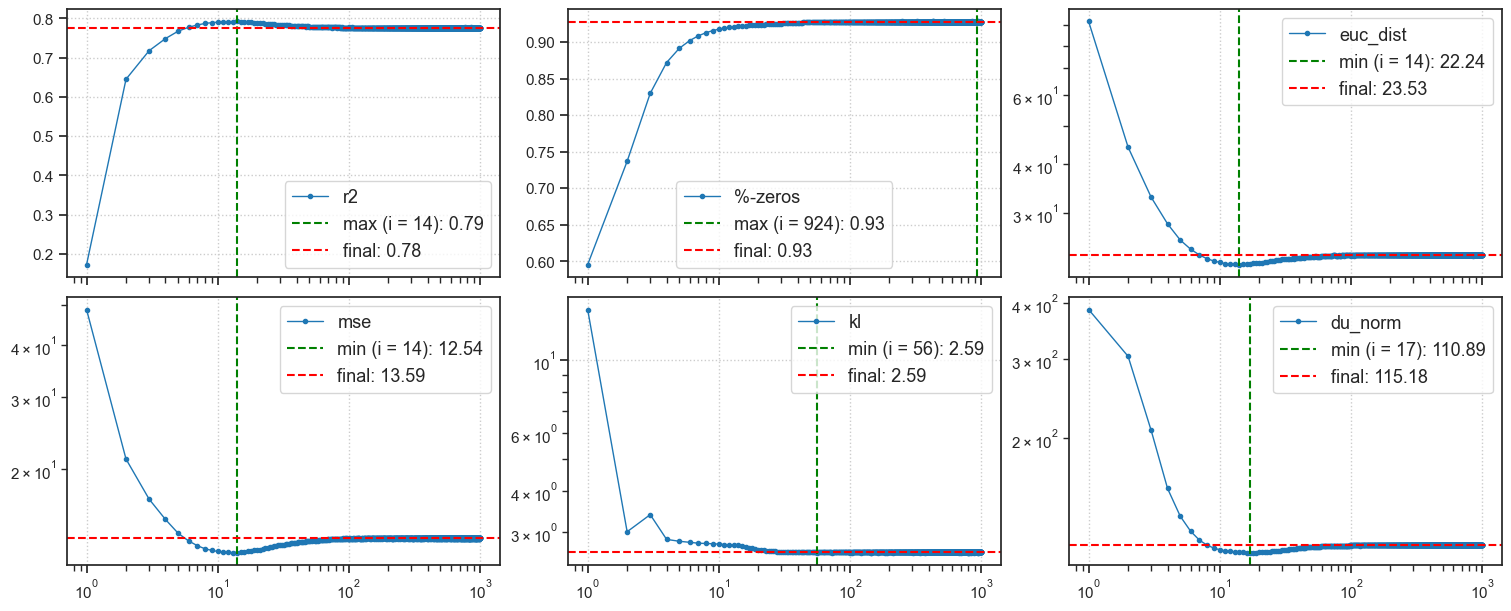

CPU times: user 2min 38s, sys: 257 ms, total: 2min 38s
Wall time: 2min 38s


In [9]:
%%time

results = tr.analysis(feeder_omni, t_total=1000, n_data_batches=-1)
_ = plot_convergence(results=results, color='C0')

### xtract emnist ftrs

In [10]:
output = tr.xtract_ftr(
    data=feeder_omni,
    t_total=1000,
    save_freq=1,
    data_batch_sz=64,
    n_data_batches=1,
    return_recon=True,
    verbose=False,
)
list(output)

['r2', 'mse', 'du_norm_0', 'samples', 'state_0', 'recon', 'true', 'times']

### save animation mp4

In [11]:
rng = get_rng(4)

sample_ids = rng.choice(
    range(len(output['true'])),
    replace=False,
    size=12,
)

In [12]:
%%time

_ = animate_recons(
    save_file=pjoin(anim_dir, 'mnist-to-omni_rotate-4'),
    recon=output['recon'][sample_ids],
    true=output['true'][sample_ids],
    n_samples=12,
    # dry_run=True,
)

CPU times: user 2min 58s, sys: 3.99 s, total: 3min 2s
Wall time: 3min 6s


## MNIST to EMNIST generalize?

### load MNIST model

In [13]:
a = 'poisson_MNIST+rotate_t-(16,16)_b-1_kms-(128,8,3)_fwd-(3,7)_prob_<ngd|lin>'
b = 'b200-ep200-lr(0.001)_temp(0.05)_gr(150)_fwd:lamb3+z7_fit:dt+sig_ClampDec:1.15_(2025_08_26,10:47)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

200

### make EMNIST feeder

In [14]:
from main.datafeeder import RotateFeeder

vld_emnist = make_dataset('EMNIST', device=tr.feeder_vld.device)[1]

feeder_emnist = tr.feeder_vld.fork(
    x=vld_emnist[0],
    y=vld_emnist[1],
    shuffle=True,
)
feeder_emnist.apply_anneal(-1)

4.0

In [15]:
tr.feeder_vld.n_samples, feeder_emnist.n_samples

(10000, 20800)

100%|█████████████████████████████████| 50/50 [03:12<00:00,  3.85s/it]


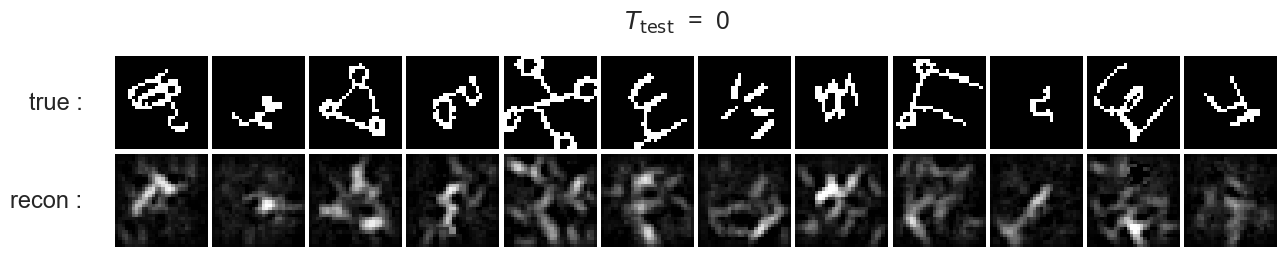

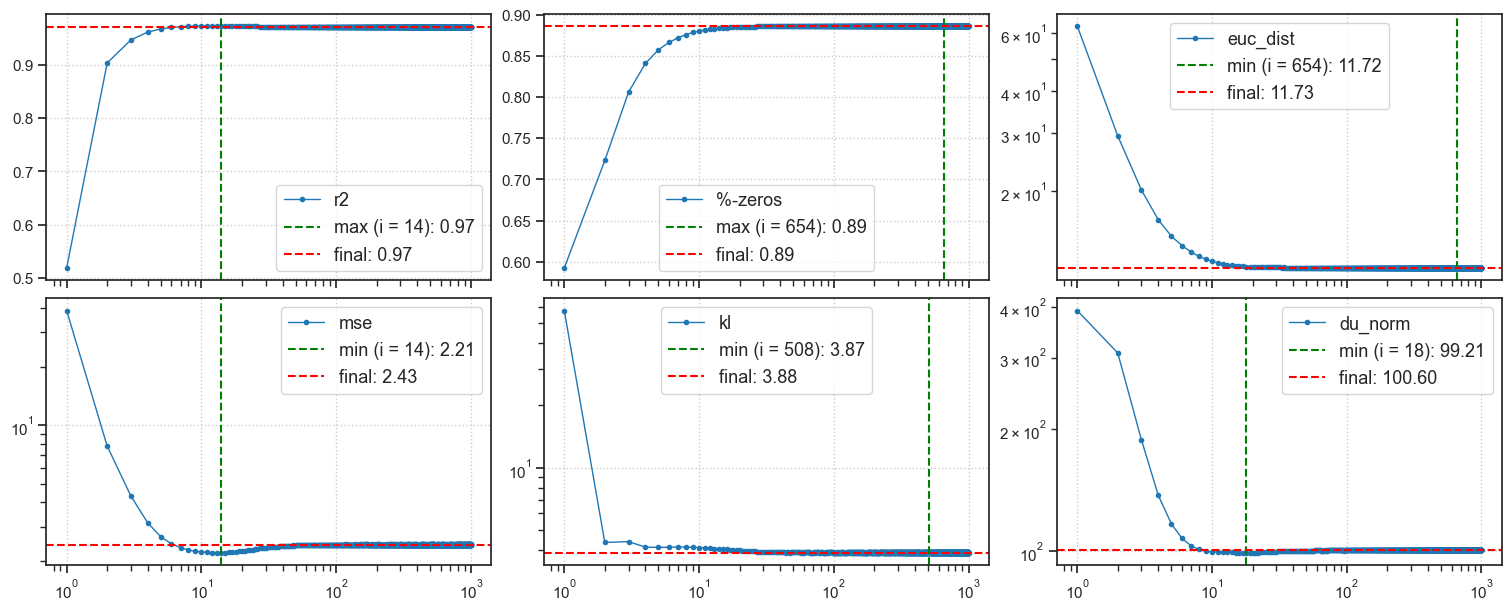

CPU times: user 3min 13s, sys: 54.5 ms, total: 3min 13s
Wall time: 3min 13s


In [16]:
%%time

results = tr.analysis(feeder_emnist, t_total=1000, n_data_batches=-1)
_ = plot_convergence(results=results, color='C0')

### xtract emnist ftrs

In [17]:
output = tr.xtract_ftr(
    data=feeder_emnist,
    t_total=1000,
    save_freq=1,
    data_batch_sz=64,
    n_data_batches=1,
    return_recon=True,
    verbose=False,
)
list(output)

['r2', 'mse', 'du_norm_0', 'samples', 'state_0', 'recon', 'true', 'times']

### save animation mp4

In [18]:
rng = get_rng(1)

sample_ids = rng.choice(
    range(len(output['true'])),
    replace=False,
    size=12,
)

In [19]:
%%time

_ = animate_recons(
    save_file=pjoin(anim_dir, 'mnist-to-emnist_rotate-4'),
    recon=output['recon'][sample_ids],
    true=output['true'][sample_ids],
    n_samples=12,
    # dry_run=True,
)

CPU times: user 2min 59s, sys: 3.9 s, total: 3min 2s
Wall time: 3min 6s


## Load model (Kyoto)

In [4]:
a = 'poisson_Kyoto-wht+translate_t-(32,32)_b-1_kms-(256,6,4)_fwd-(3,5)_prob_<ngd|lin>'
b = 'b100-ep600-lr(0.001)_temp(0.05)_gr(200)_fwd:u3+z5_fit:dt+sig_(2025_08_26,16:18)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

600

### sanity check

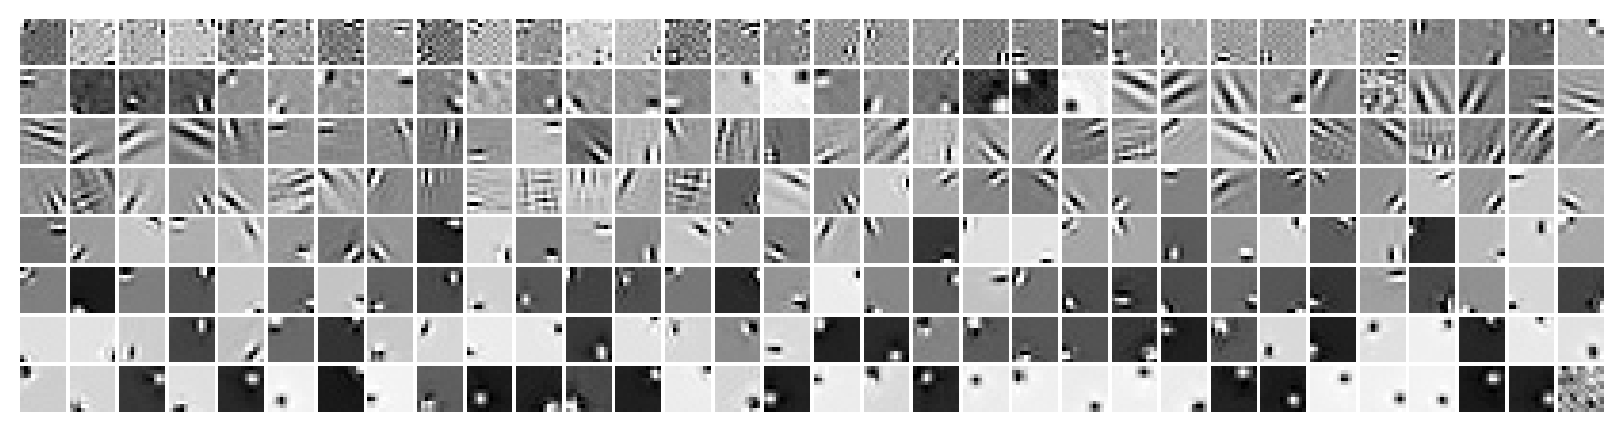

In [5]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

100%|███████████████████████████████████| 5/5 [00:12<00:00,  2.45s/it]


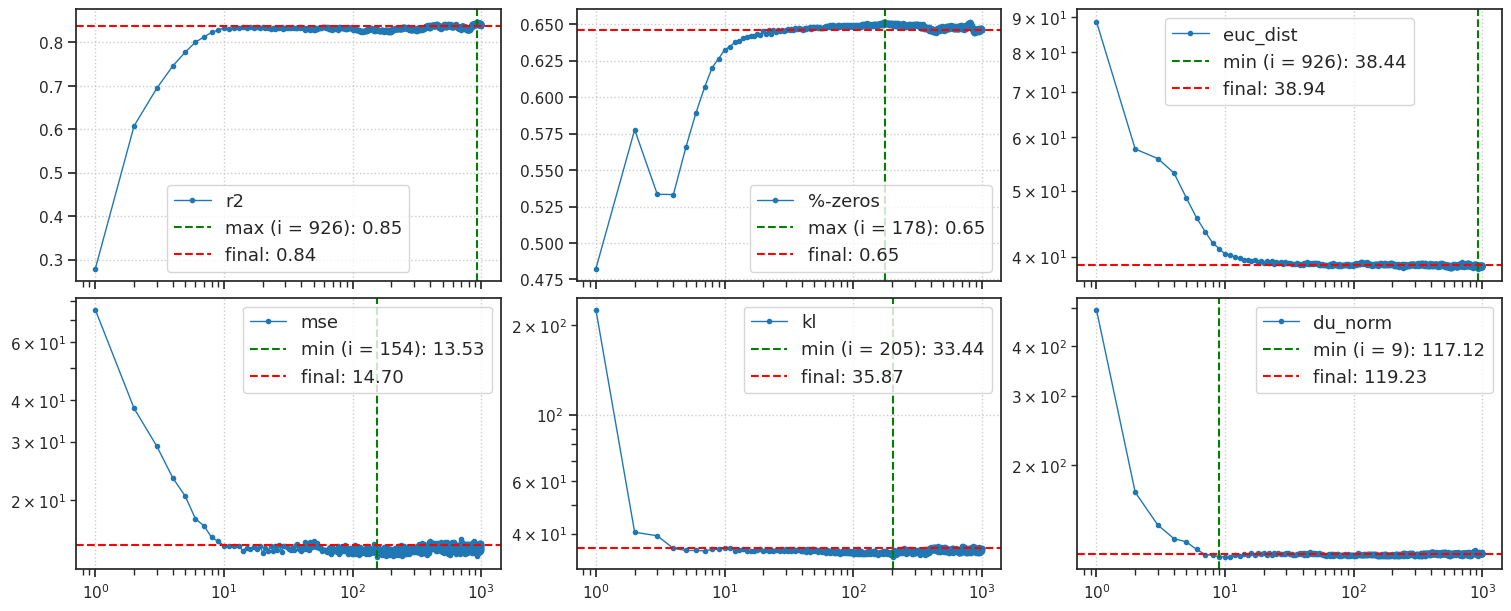

CPU times: user 13.1 s, sys: 77.1 ms, total: 13.2 s
Wall time: 13.2 s


In [6]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=5)
_ = plot_convergence(results=results, color='C0')

In [7]:
lr_inner = tuple(dt.exp() for dt in tr.model.layer.log_dt)
print(f"learned inner learning rates (dt):\n{lr_inner}\n")

learned inner learning rates (dt):
(tensor([0.1620], device='cuda:0', grad_fn=<ExpBackward0>),)

### xtract ftrs

In [8]:
output = tr.xtract_ftr(
    data='vld',
    t_total=1000,
    save_freq=1,
    data_batch_sz=64,
    n_data_batches=1,
    return_recon=True,
    verbose=False,
)
list(output)

['r2', 'mse', 'du_norm_0', 'samples', 'state_0', 'recon', 'true', 'times']

In [9]:
output['true'].shape, output['recon'].shape

((64, 1000, 1, 32, 32), (64, 1000, 1, 32, 32))

In [10]:
rng = get_rng(0)

sample_ids = rng.choice(
    range(len(output['true'])),
    replace=False,
    size=12,
)

### save animation mp4

CPU times: user 2min 17s, sys: 3.96 s, total: 2min 21s
Wall time: 2min 24s


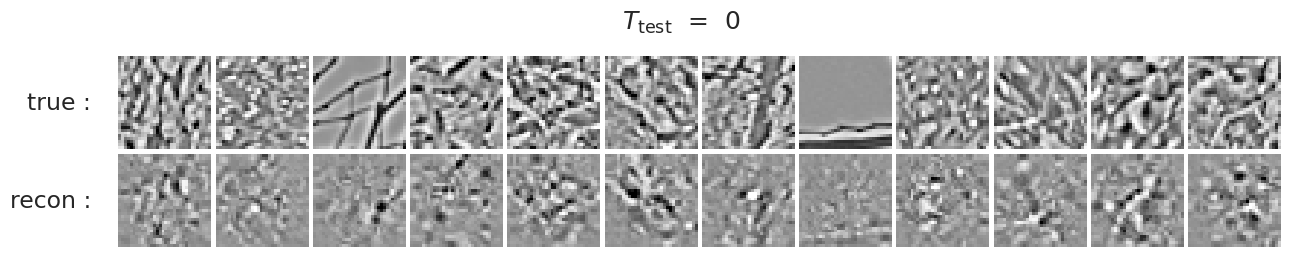

In [11]:
%%time

_ = animate_recons(
    save_file=pjoin(anim_dir, 'kyoto_translate_crop32'),
    recon=output['recon'][sample_ids],
    true=output['true'][sample_ids],
    symmetric_vrange=True,
    # dry_run=True,
)

## Load model (MNIST)

In [4]:
a = 'poisson_MNIST+rotate_t-(16,16)_b-1_kms-(128,8,3)_fwd-(3,7)_prob_<ngd|lin>'
b = 'b200-ep200-lr(0.001)_temp(0.05)_gr(150)_fwd:lamb3+z7_fit:dt+sig_ClampDec:1.15_(2025_08_26,10:47)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

200

### sanity check

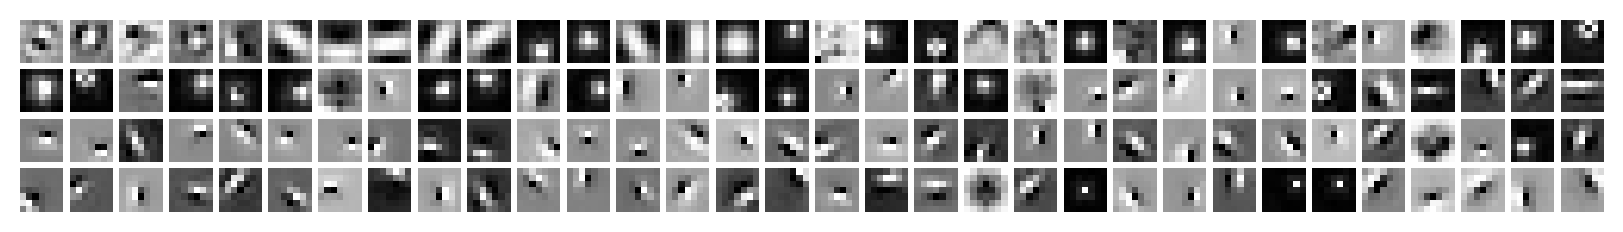

In [5]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

100%|███████████████████████████████████| 5/5 [00:19<00:00,  3.91s/it]


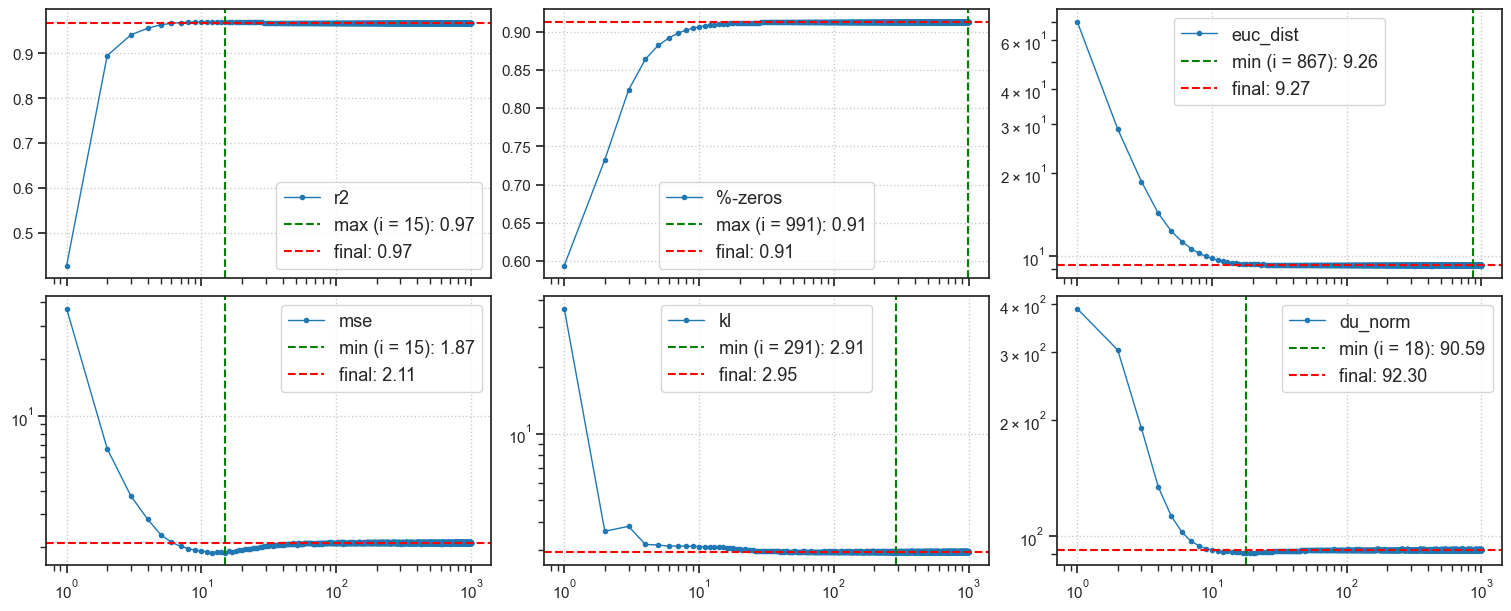

CPU times: user 23.5 s, sys: 242 ms, total: 23.8 s
Wall time: 20.8 s


In [6]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=5)
_ = plot_convergence(results=results, color='C0')

In [7]:
lr_inner = tuple(dt.exp() for dt in tr.model.layer.log_dt)
print(f"learned inner learning rates (dt):\n{lr_inner}\n")

learned inner learning rates (dt):
(tensor([0.2258], device='cuda:0', grad_fn=<ExpBackward0>),)

### xtract ftrs

In [8]:
output = tr.xtract_ftr(
    data='vld',
    t_total=1000,
    save_freq=1,
    data_batch_sz=64,
    n_data_batches=1,
    return_recon=True,
    verbose=False,
)
list(output)

['r2', 'mse', 'du_norm_0', 'samples', 'state_0', 'recon', 'true', 'times']

In [9]:
output['true'].shape, output['recon'].shape

((64, 1000, 1, 28, 28), (64, 1000, 1, 28, 28))

### save animation mp4

In [10]:
%%time

_ = animate_recons(
    save_file=pjoin(anim_dir, 'mnist_rotate-4'),
    recon=output['recon'],
    true=output['true'],
    n_samples=12,
)

CPU times: user 3min 5s, sys: 3.99 s, total: 3min 9s
Wall time: 3min 13s
